# Previsão de Ações do Setor de Energia com LSTM
**Carteira:** XOM, CVX, SLB, HAL — NYSE  
**Objetivo:** Prever o log-return do dia seguinte (regressão multivariada) e comparar a estratégia gerada contra buy & hold.

| Período | Datas | Dias aprox. |
|---------|-------|-------------|
| Treino | 2010–2019 | ~2500 |
| Teste | 2023–2025 | ~600 |
| Excluído | 2020–2022 | pandemia — regime não repetível |

---
### Estrutura
1. Imports e configuração
2. Coleta de dados
3. Engenharia de features
4. Pipeline — janelas, normalização, split treino/teste
5. Arquitetura LSTM
6. Treino com early stopping
7. Threshold dinâmico — calibração no treino
8. Avaliação estatística no teste
9. Estratégia de trading
10. Comparação com buy & hold
11. Visualizações e análise final

---
## 1. Imports e Configuração

In [22]:
#!pip install torch yfinance pandas-ta scikit-learn seaborn matplotlib scipy

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import yfinance as yf
import pandas_ta as ta

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Reprodutibilidade ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}  |  pandas-ta: {ta.version}')

# ── Helper: detecta nomes de colunas do pandas-ta independente da versão ──────
def get_col(df, prefix):
    cols = [c for c in df.columns if str(c).startswith(prefix)]
    if not cols:
        raise KeyError(f"Prefixo '{prefix}' não encontrado. Disponíveis: {list(df.columns)}")
    return cols[0]

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})
CORES = {'XOM': '#1D9E75', 'CVX': '#534AB7', 'SLB': '#D85A30', 'HAL': '#BA7517'}
print('OK')

Device: cuda  |  PyTorch: 2.9.0+cu126  |  pandas-ta: 0.4.71b0
OK


---
## 2. Coleta de Dados

In [23]:
TICKERS_ATIVOS = ['XOM', 'CVX', 'SLB', 'HAL']
TICKERS_MACRO  = ['CL=F', 'BZ=F', 'NG=F']

# 2020-2022 excluído — pandemia
PERIODOS = [
    ('2010-01-01', '2019-12-31'),
    ('2023-01-01', '2025-12-31'),
]

def baixar_concat(tickers, periodos):
    partes = [yf.download(tickers, start=s, end=e,
                          auto_adjust=True, progress=False)
              for s, e in periodos]
    return pd.concat(partes).sort_index()

raw_ativos = baixar_concat(TICKERS_ATIVOS, PERIODOS)
raw_macro  = baixar_concat(TICKERS_MACRO,  PERIODOS)

print(f'Total: {len(raw_ativos)} dias')
print(f'Treino (2010-2019): {len(raw_ativos[raw_ativos.index < "2020-01-01"])} dias')
print(f'Teste  (2023-2025): {len(raw_ativos[raw_ativos.index >= "2023-01-01"])} dias')
raw_ativos['Close'].tail(3)

Total: 3266 dias
Treino (2010-2019): 2515 dias
Teste  (2023-2025): 751 dias


Ticker,CVX,HAL,SLB,XOM
Date,,,,
2025-12-26,148.566666,27.825195,37.568459,118.321342
2025-12-29,149.527267,28.014280,37.677814,119.731941
2025-12-30,150.834473,28.352640,38.324001,120.188896


---
## 3. Engenharia de Features

13 features em 5 grupos — todas justificadas por análise de correlação e Mutual Information (ver `exploratory_analysis.ipynb`).

In [24]:
FEATURES = [
    'logret_close', 'logret_open',
    'volume_ratio',
    'sma_diff', 'ema_diff',
    'rsi14', 'macd_hist',
    'atr14', 'bb_pct_b',
    'wti_logret', 'brent_logret', 'spread_wb', 'ng_logret',
]

def calcular_features(ticker, raw_ativos, raw_macro):
    df     = pd.DataFrame(index=raw_ativos.index)
    close  = raw_ativos['Close'][ticker]
    open_  = raw_ativos['Open'][ticker]
    high   = raw_ativos['High'][ticker]
    low    = raw_ativos['Low'][ticker]
    volume = raw_ativos['Volume'][ticker]

    df['logret_close'] = np.log(close / close.shift(1))
    df['logret_open']  = np.log(open_ / close.shift(1))
    df['volume_ratio'] = volume / volume.rolling(20).mean()

    sma50  = ta.sma(close, length=50)
    sma200 = ta.sma(close, length=200)
    ema12  = ta.ema(close, length=12)
    ema26  = ta.ema(close, length=26)
    df['sma_diff'] = (sma50 - sma200) / sma200
    df['ema_diff'] = (ema12 - ema26)  / close

    df['rsi14']     = ta.rsi(close, length=14)
    macd_df         = ta.macd(close, fast=12, slow=26, signal=9)
    df['macd_hist'] = macd_df[get_col(macd_df, 'MACDh')] / close

    df['atr14']    = ta.atr(high, low, close, length=14) / close
    bb             = ta.bbands(close, length=20, std=2)
    df['bb_pct_b'] = bb[get_col(bb, 'BBP')]

    wti = np.log(raw_macro['Close']['CL=F'] / raw_macro['Close']['CL=F'].shift(1))
    brt = np.log(raw_macro['Close']['BZ=F'] / raw_macro['Close']['BZ=F'].shift(1))
    ng  = np.log(raw_macro['Close']['NG=F'] / raw_macro['Close']['NG=F'].shift(1))
    df['wti_logret']   = wti
    df['brent_logret'] = brt
    df['ng_logret']    = ng
    df['spread_wb']    = wti - brt

    df['target'] = df['logret_close'].shift(-1)
    return df.dropna()


features_ativos = {t: calcular_features(t, raw_ativos, raw_macro)
                   for t in TICKERS_ATIVOS}

for t, df in features_ativos.items():
    n_tr = len(df[df.index < '2020-01-01'])
    n_te = len(df[df.index >= '2023-01-01'])
    print(f'{t}:  treino={n_tr}  teste={n_te}')

XOM:  treino=2258  teste=749
CVX:  treino=2258  teste=749
SLB:  treino=2258  teste=749
HAL:  treino=2258  teste=749


---
## 4. Pipeline de Dados

**Split:** treino = 2010–2019 | teste = 2023–2025. Sem validação — o threshold é calibrado no treino (seção 7).  
**Normalização:** `StandardScaler` ajustado **apenas no treino**, aplicado no teste. Evita data leakage.

In [25]:
LOOKBACK = 20
BATCH    = 64

def criar_janelas(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

class SerieDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


def preparar_pipeline(features_ativos, tickers, lookback, batch):
    scalers  = {}
    janelas  = {'treino': {}, 'teste': {}}

    for t in tickers:
        df = features_ativos[t]
        tr = df[df.index <  '2020-01-01']
        te = df[df.index >= '2023-01-01']

        sc = StandardScaler()
        X_tr = sc.fit_transform(tr[FEATURES].values)
        X_te = sc.transform(te[FEATURES].values)
        scalers[t] = sc

        janelas['treino'][t] = criar_janelas(X_tr, tr['target'].values, lookback)
        janelas['teste'][t]  = criar_janelas(X_te, te['target'].values, lookback)

    def concat(split):
        Xs = np.concatenate([janelas[split][t][0] for t in tickers])
        ys = np.concatenate([janelas[split][t][1] for t in tickers])
        return Xs, ys

    X_tr, y_tr = concat('treino')
    X_te, y_te = concat('teste')

    loader_treino = DataLoader(SerieDataset(X_tr, y_tr), batch_size=batch, shuffle=False)
    loader_teste  = DataLoader(SerieDataset(X_te, y_te), batch_size=batch, shuffle=False)

    print(f'Treino: {len(X_tr):>5} janelas  ({len(X_tr)//len(tickers)} por ativo)')
    print(f'Teste:  {len(X_te):>5} janelas  ({len(X_te)//len(tickers)} por ativo)')

    return loader_treino, loader_teste, janelas, scalers


loader_treino, loader_teste, janelas, scalers = preparar_pipeline(
    features_ativos, TICKERS_ATIVOS, LOOKBACK, BATCH
)

Treino:  8952 janelas  (2238 por ativo)
Teste:   2916 janelas  (729 por ativo)


---
## 5. Arquitetura LSTM

```
Entrada (batch, 20, 13)  →  LSTM × 2 camadas (hidden=128, dropout=0.2)  →  Linear(128, 1)
```

**Sem ativação na saída:** log-returns são valores reais contínuos — qualquer ativação restringiria o intervalo artificialmente.  
**Loss híbrida:** `RMSE + λ·(1 − Sharpe normalizado)` — penaliza tanto erro de previsão quanto sinais de trading ruins.

In [26]:
class EnergyLSTM(nn.Module):
    def __init__(self, input_size=13, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)  # sem ativação — regressão

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


def sharpe_loss(y_pred, y_true, lamb=0.3, eps=1e-8):
    rmse     = torch.sqrt(torch.mean((y_pred.squeeze() - y_true) ** 2))
    retornos = y_true * torch.sign(y_pred.squeeze())
    sharpe_n = torch.tanh(retornos.mean() / (retornos.std() + eps))
    return rmse + lamb * (1.0 - sharpe_n)


modelo = EnergyLSTM(input_size=len(FEATURES)).to(DEVICE)
total  = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(modelo)
print(f'\nParâmetros treináveis: {total:,}')

EnergyLSTM(
  (lstm): LSTM(13, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Parâmetros treináveis: 205,441


---
## 6. Treino com Early Stopping

Sem validação separada — o early stopping monitora a **loss no próprio treino**.  
Para evitar overfitting usamos: dropout 0.2, gradient clipping e ReduceLROnPlateau.

In [27]:
LR            = 1e-3
EPOCHS        = 100
PATIENCE      = 10
LAMBDA_SHARPE = 0.3

otimizador = torch.optim.Adam(modelo.parameters(), lr=LR)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    otimizador, mode='min', patience=5, factor=0.5
)

def treinar_epoca(modelo, loader):
    modelo.train()
    total = 0.0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        otimizador.zero_grad()
        loss = sharpe_loss(modelo(X_b), y_b, LAMBDA_SHARPE)
        loss.backward()
        nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
        otimizador.step()
        total += loss.item()
    return total / len(loader)


historico    = []
melhor_loss  = float('inf')
melhor_pesos = None
paciencia    = 0

for epoch in range(1, EPOCHS + 1):
    loss = treinar_epoca(modelo, loader_treino)
    historico.append(loss)
    scheduler.step(loss)

    if loss < melhor_loss:
        melhor_loss  = loss
        melhor_pesos = {k: v.clone() for k, v in modelo.state_dict().items()}
        paciencia    = 0
    else:
        paciencia += 1

    if epoch % 10 == 0 or epoch == 1:
        lr_atual = otimizador.param_groups[0]['lr']
        print(f'Época {epoch:>3}  loss={loss:.5f}  lr={lr_atual:.2e}  paciência={paciencia}/{PATIENCE}')

    if paciencia >= PATIENCE:
        print(f'\nEarly stopping na época {epoch}. Melhor loss: {melhor_loss:.5f}')
        break

modelo.load_state_dict(melhor_pesos)
print('Melhores pesos restaurados.')

Época   1  loss=0.31230  lr=1.00e-03  paciência=0/10
Época  10  loss=0.28247  lr=1.00e-03  paciência=0/10
Época  20  loss=0.23253  lr=1.00e-03  paciência=0/10
Época  30  loss=0.18457  lr=1.00e-03  paciência=0/10
Época  40  loss=0.14504  lr=1.00e-03  paciência=1/10
Época  50  loss=0.12121  lr=1.00e-03  paciência=0/10
Época  60  loss=0.10161  lr=1.00e-03  paciência=1/10
Época  70  loss=0.08958  lr=1.00e-03  paciência=0/10
Época  80  loss=0.08586  lr=1.00e-03  paciência=1/10
Época  90  loss=0.08393  lr=1.00e-03  paciência=3/10
Época 100  loss=0.07684  lr=1.00e-03  paciência=0/10
Melhores pesos restaurados.


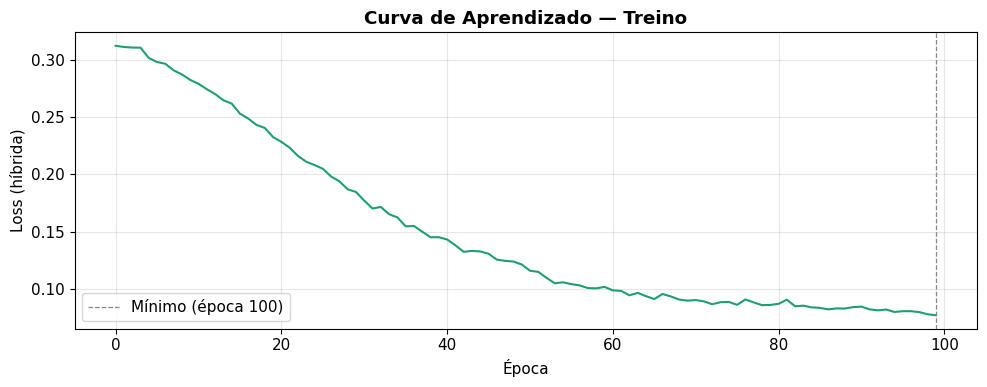

In [28]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(historico, color='#1D9E75', linewidth=1.5)
ax.axvline(np.argmin(historico), color='#888', linestyle='--',
           linewidth=0.9, label=f'Mínimo (época {np.argmin(historico)+1})')
ax.set_xlabel('Época')
ax.set_ylabel('Loss (híbrida)')
ax.set_title('Curva de Aprendizado — Treino', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('curva_aprendizado.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Threshold Dinâmico — Calibração no Treino

O threshold filtra sinais fracos: só opera quando `|ŷ| > threshold`.  

**Por que calibrar no treino e não fixar um valor:**  
A distribuição das previsões varia por modelo e por ativo. Um threshold fixo de `0.003` pode ser muito restritivo para um ativo volátil (HAL) e muito permissivo para um estável (XOM). O threshold dinâmico é definido como um **percentil da distribuição de `|ŷ|` no treino** — por exemplo, percentil 30 significa "opera apenas nos 70% de dias com sinal mais forte".

Testamos vários percentis e escolhemos o que **maximiza o Sharpe anualizado no treino**.

In [29]:
def prever(modelo, X_np):
    modelo.eval()
    with torch.no_grad():
        return modelo(torch.from_numpy(X_np).to(DEVICE)).cpu().numpy().squeeze()

def retornos_estrategia(y_true, y_pred, threshold):
    sinais = np.where(np.abs(y_pred) > threshold, np.sign(y_pred), 0.0)
    return sinais * y_true

def sharpe_anualizado(retornos, dias_ano=252):
    std = retornos.std()
    return (retornos.mean() / std * np.sqrt(dias_ano)) if std > 1e-10 else 0.0

def max_drawdown(curva_capital):
    pico = np.maximum.accumulate(curva_capital)
    return ((curva_capital - pico) / pico).min()


# ── Previsões no treino (para calibração) ─────────────────────────────────────
previsoes_treino = {}
for t in TICKERS_ATIVOS:
    X_tr, y_tr = janelas['treino'][t]
    previsoes_treino[t] = {'y_pred': prever(modelo, X_tr), 'y_true': y_tr}

# ── Busca do percentil ótimo ───────────────────────────────────────────────────
# Percentis candidatos — começamos em p30 para garantir que pelo menos
# 30% dos dias fiquem em cash. Percentis baixos (p0, p10) colapsam para
# thresholds na casa de 0.000001 porque a distribuição de |ŷ| é muito
# concentrada perto de zero — o filtro se torna inefetivo.
PERCENTIS = [30, 40, 50, 60, 70, 80]
# p30 → opera os 70% de dias com maior |ŷ|
# p50 → opera os 50% de dias com maior |ŷ|
# p80 → opera apenas os 20% de dias com maior convicção

print('Calibração do threshold dinâmico — Sharpe médio no treino:')
print(f'  {"Percentil":<12} {"Threshold médio":<18} {"Sharpe médio":<15} {"% operando"}') 
print('  ' + '-'*58)

sharpes_por_percentil = {}
thresholds_por_ativo  = {}   # threshold individual por ativo

for pct in PERCENTIS:
    sharpes    = []
    thresholds = []
    cobert     = []
    for t in TICKERS_ATIVOS:
        yp  = previsoes_treino[t]['y_pred']
        yt  = previsoes_treino[t]['y_true']
        thr = np.percentile(np.abs(yp), pct)
        ret = retornos_estrategia(yt, yp, thr)
        sharpes.append(sharpe_anualizado(ret))
        thresholds.append(thr)
        cobert.append(np.mean(np.abs(yp) > thr))
    media_sharpe = np.mean(sharpes)
    media_thr    = np.mean(thresholds)
    media_cob    = np.mean(cobert)
    sharpes_por_percentil[pct] = media_sharpe
    print(f'  p{pct:<11} {media_thr:<18.5f} {media_sharpe:<15.3f} {media_cob:.1%}')

PERCENTIL_OTIMO = max(sharpes_por_percentil, key=sharpes_por_percentil.get)
print(f'\nPercentil ótimo: p{PERCENTIL_OTIMO}')

# Calcula threshold individual por ativo com o percentil ótimo
for t in TICKERS_ATIVOS:
    yp = previsoes_treino[t]['y_pred']
    thresholds_por_ativo[t] = np.percentile(np.abs(yp), PERCENTIL_OTIMO)
    print(f'  Threshold {t}: {thresholds_por_ativo[t]:.6f}')

Calibração do threshold dinâmico — Sharpe médio no treino:
  Percentil    Threshold médio    Sharpe médio    % operando
  ----------------------------------------------------------
  p30          0.00602            10.585          70.0%
  p40          0.00830            9.955           60.0%
  p50          0.01092            9.126           50.0%
  p60          0.01392            8.142           40.0%
  p70          0.01764            6.982           30.0%
  p80          0.02258            5.595           20.0%

Percentil ótimo: p30
  Threshold XOM: 0.005016
  Threshold CVX: 0.005788
  Threshold SLB: 0.006711
  Threshold HAL: 0.006546


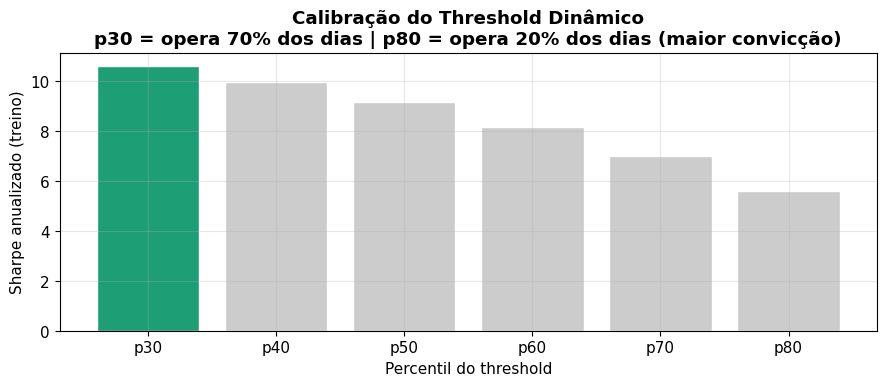

In [30]:
# Visualização: Sharpe vs percentil de threshold
fig, ax = plt.subplots(figsize=(9, 4))
sharpe_vals = [sharpes_por_percentil[p] for p in PERCENTIS]
cores_barras = ['#1D9E75' if p == PERCENTIL_OTIMO else '#cccccc' for p in PERCENTIS]
ax.bar([f'p{p}' for p in PERCENTIS], sharpe_vals, color=cores_barras, edgecolor='white')
ax.axhline(0, color='#888', linewidth=0.7)
ax.set_xlabel('Percentil do threshold')
ax.set_ylabel('Sharpe anualizado (treino)')
ax.set_title('Calibração do Threshold Dinâmico\n'
             'p30 = opera 70% dos dias | p80 = opera 20% dos dias (maior convicção)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('calibracao_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Avaliação Estatística no Teste (2023–2025)

In [31]:
def acuracia_direcional(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

previsoes_teste = {}
metricas_estat  = {}

for t in TICKERS_ATIVOS:
    X_te, y_te = janelas['teste'][t]
    y_pred = prever(modelo, X_te)
    previsoes_teste[t] = {'y_true': y_te, 'y_pred': y_pred}

    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    dacc = acuracia_direcional(y_te, y_pred)

    # Acurácia direcional apenas nos dias que passam pelo threshold
    thr  = thresholds_por_ativo[t]
    mask = np.abs(y_pred) > thr
    dacc_filtrado = acuracia_direcional(y_te[mask], y_pred[mask]) if mask.sum() > 0 else np.nan

    metricas_estat[t] = {
        'RMSE': rmse, 'MAE': mae, 'R²': r2,
        'Dir.Acc. (todos)': dacc,
        'Dir.Acc. (filtrado)': dacc_filtrado,
        'Dias filtrados': int(mask.sum()),
    }

df_estat = pd.DataFrame(metricas_estat).T.round(4)
print('=== Métricas Estatísticas — Teste 2023–2025 ===')
print(df_estat.to_string())

=== Métricas Estatísticas — Teste 2023–2025 ===
       RMSE     MAE      R²  Dir.Acc. (todos)  Dir.Acc. (filtrado)  Dias filtrados
XOM  0.0210  0.0165 -1.1865            0.4911               0.4832           536.0
CVX  0.0200  0.0152 -1.0630            0.5144               0.5198           481.0
SLB  0.0254  0.0193 -0.5336            0.4925               0.4812           478.0
HAL  0.0270  0.0201 -0.4017            0.4829               0.4656           451.0


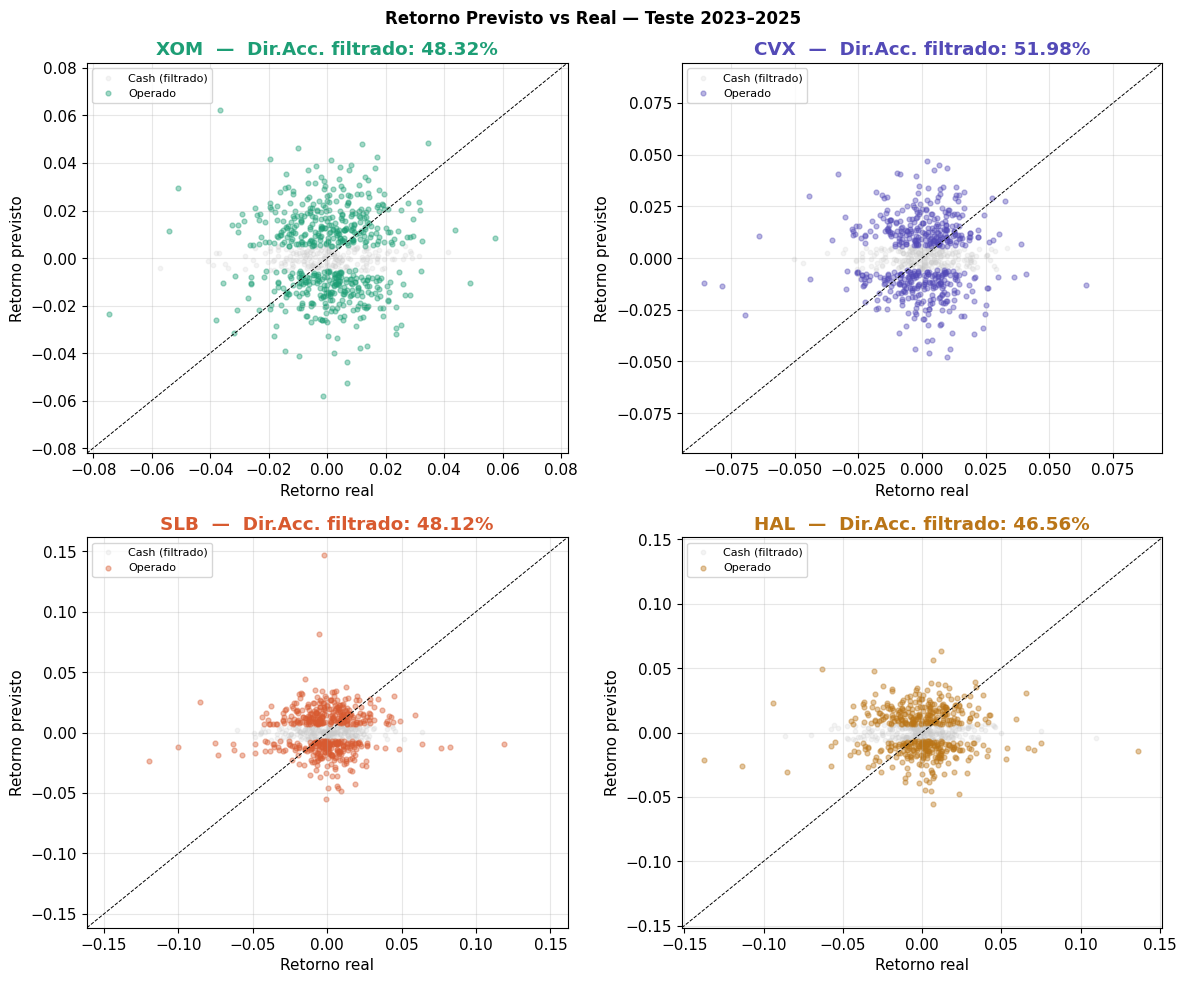

In [32]:
# Scatter retorno previsto vs real
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Retorno Previsto vs Real — Teste 2023–2025', fontsize=12, fontweight='bold')

for ax, t in zip(axes.flat, TICKERS_ATIVOS):
    yt = previsoes_teste[t]['y_true']
    yp = previsoes_teste[t]['y_pred']
    thr = thresholds_por_ativo[t]
    mask = np.abs(yp) > thr

    ax.scatter(yt[~mask], yp[~mask], alpha=0.2, s=10, color='#cccccc', label='Cash (filtrado)')
    ax.scatter(yt[mask],  yp[mask],  alpha=0.4, s=12, color=CORES[t],  label='Operado')
    lim = max(np.abs(yt).max(), np.abs(yp).max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.7)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel('Retorno real')
    ax.set_ylabel('Retorno previsto')
    dacc_f = metricas_estat[t]['Dir.Acc. (filtrado)']
    ax.set_title(f'{t}  —  Dir.Acc. filtrado: {dacc_f:.2%}', fontweight='bold', color=CORES[t])
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('scatter_previsao.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Estratégia de Trading

Regra: **long** se `ŷ > threshold`, **short** se `ŷ < −threshold`, **cash** caso contrário.  
Threshold individual por ativo — calibrado no percentil ótimo da distribuição de treino.

In [33]:
def calcular_metricas_trading(retornos, nome, tipo):
    curva     = np.exp(np.cumsum(retornos))
    ret_total = curva[-1] - 1
    sharpe    = sharpe_anualizado(retornos)
    mdd       = max_drawdown(curva)
    dias_op   = int(np.sum(retornos != 0))
    pct_op    = dias_op / len(retornos)
    return {
        'Nome': nome, 'Tipo': tipo,
        'Retorno total': ret_total,
        'Sharpe':        sharpe,
        'Max Drawdown':  mdd,
        'Dias operando': dias_op,
        '% operando':    pct_op,
    }, curva


resultados = []
curvas     = {}

for t in TICKERS_ATIVOS:
    yt   = previsoes_teste[t]['y_true']
    yp   = previsoes_teste[t]['y_pred']
    thr  = thresholds_por_ativo[t]

    # LSTM com threshold dinâmico
    ret_lstm = retornos_estrategia(yt, yp, thr)
    m, c     = calcular_metricas_trading(ret_lstm, t, 'LSTM')
    m['Dir.Acc.'] = metricas_estat[t]['Dir.Acc. (filtrado)']
    resultados.append(m)
    curvas[f'LSTM_{t}'] = c

    # Buy & hold
    ret_bh   = yt
    m_bh, c_bh = calcular_metricas_trading(ret_bh, t, 'B&H')
    m_bh['Dir.Acc.'] = np.nan
    resultados.append(m_bh)
    curvas[f'BH_{t}'] = c_bh

# Carteira equal-weight
ret_lstm_cart = np.mean(
    [retornos_estrategia(previsoes_teste[t]['y_true'],
                         previsoes_teste[t]['y_pred'],
                         thresholds_por_ativo[t])
     for t in TICKERS_ATIVOS], axis=0)
ret_bh_cart = np.mean([previsoes_teste[t]['y_true'] for t in TICKERS_ATIVOS], axis=0)

m_lc, c_lc = calcular_metricas_trading(ret_lstm_cart, 'Carteira', 'LSTM')
m_lc['Dir.Acc.'] = np.nan
resultados.append(m_lc)
curvas['LSTM_Carteira'] = c_lc

m_bc, c_bc = calcular_metricas_trading(ret_bh_cart, 'Carteira', 'B&H')
m_bc['Dir.Acc.'] = np.nan
resultados.append(m_bc)
curvas['BH_Carteira'] = c_bc

df_res = pd.DataFrame(resultados)

# Formata para exibição
df_print = df_res.copy()
df_print['Retorno total'] = df_print['Retorno total'].map('{:.2%}'.format)
df_print['Sharpe']        = df_print['Sharpe'].round(3)
df_print['Max Drawdown']  = df_print['Max Drawdown'].map('{:.2%}'.format)
df_print['% operando']    = df_print['% operando'].map('{:.1%}'.format)
df_print['Dir.Acc.']      = df_print['Dir.Acc.'].apply(
    lambda x: f'{x:.2%}' if pd.notna(x) else '—')

cols = ['Nome', 'Tipo', 'Retorno total', 'Sharpe', 'Max Drawdown',
        'Dias operando', '% operando', 'Dir.Acc.']
print('\n' + '='*80)
print('RESULTADOS — Teste 2023–2025')
print('='*80)
print(df_print[df_print['Nome'] != 'Carteira'][cols].to_string(index=False))
print('\n--- Carteira igual ponderada ---')
print(df_print[df_print['Nome'] == 'Carteira'][cols].to_string(index=False))
print(f'\nThreshold: percentil p{PERCENTIL_OTIMO} da distribuição de |ŷ| no treino')
print(f'Sharpe anualizado: 252 dias de pregão/ano')


RESULTADOS — Teste 2023–2025
Nome Tipo Retorno total  Sharpe Max Drawdown  Dias operando % operando Dir.Acc.
 XOM LSTM        -2.44%  -0.045      -31.19%            535      73.4%   48.32%
 XOM  B&H        17.59%   0.248      -18.92%            726      99.6%        —
 CVX LSTM        41.13%   0.639      -15.37%            481      66.0%   51.98%
 CVX  B&H         1.20%   0.019      -20.64%            729     100.0%        —
 SLB LSTM        38.58%   0.410      -36.22%            478      65.6%   48.12%
 SLB  B&H       -25.32%  -0.309      -46.58%            725      99.5%        —
 HAL LSTM       -14.86%  -0.191      -37.40%            446      61.2%   46.56%
 HAL  B&H       -24.59%  -0.269      -53.56%            722      99.0%        —

--- Carteira igual ponderada ---
    Nome Tipo Retorno total  Sharpe Max Drawdown  Dias operando % operando Dir.Acc.
Carteira LSTM        12.90%   0.236      -20.43%            705      96.7%        —
Carteira  B&H        -9.52%  -0.135      -33.27%

---
## 10. Comparação com Buy & Hold — Visualizações

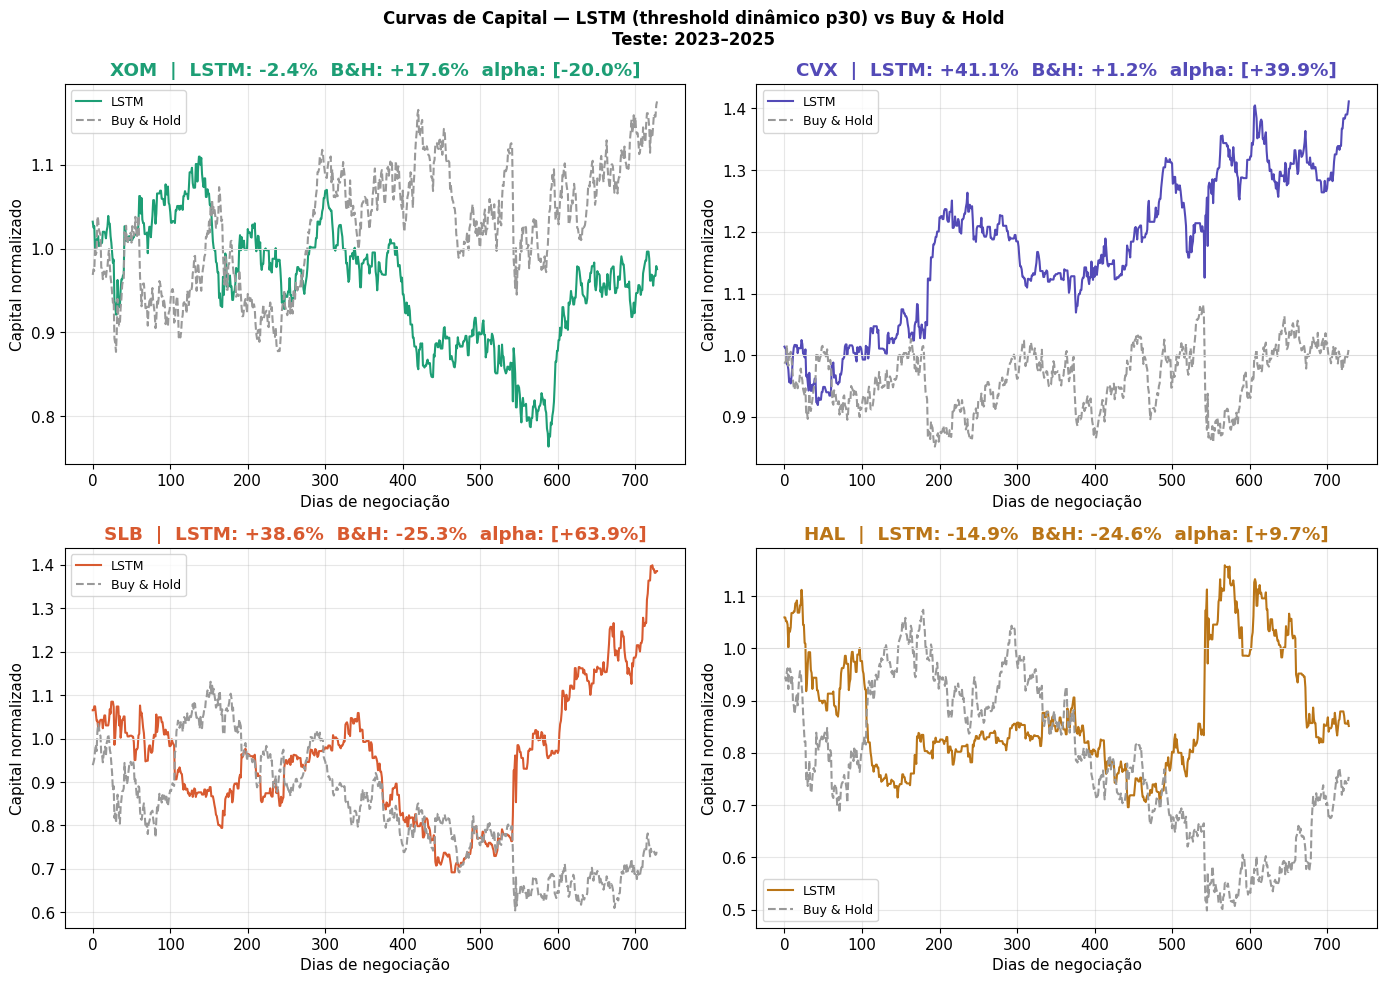

In [34]:
# Plot 1: Curvas de capital por ativo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Curvas de Capital — LSTM (threshold dinâmico p{PERCENTIL_OTIMO}) vs Buy & Hold\n'
             'Teste: 2023–2025', fontsize=12, fontweight='bold')

for ax, t in zip(axes.flat, TICKERS_ATIVOS):
    n = len(curvas[f'LSTM_{t}'])
    x = np.arange(n)
    ax.plot(x, curvas[f'LSTM_{t}'], color=CORES[t],  linewidth=1.5, label='LSTM')
    ax.plot(x, curvas[f'BH_{t}'],   color='#999999', linewidth=1.5,
            linestyle='--', label='Buy & Hold')
    ax.axhline(1.0, color='#dddddd', linewidth=0.7)

    ret_l = curvas[f'LSTM_{t}'][-1] - 1
    ret_b = curvas[f'BH_{t}'][-1]   - 1
    alpha = ret_l - ret_b
    cor_alpha = '#1D9E75' if alpha >= 0 else '#D85A30'
    ax.set_title(f'{t}  |  LSTM: {ret_l:+.1%}  B&H: {ret_b:+.1%}  '
                 f'alpha: [{alpha:+.1%}]',
                 fontweight='bold', color=CORES[t])
    ax.set_xlabel('Dias de negociação')
    ax.set_ylabel('Capital normalizado')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('curvas_capital_ativos.png', dpi=150, bbox_inches='tight')
plt.show()

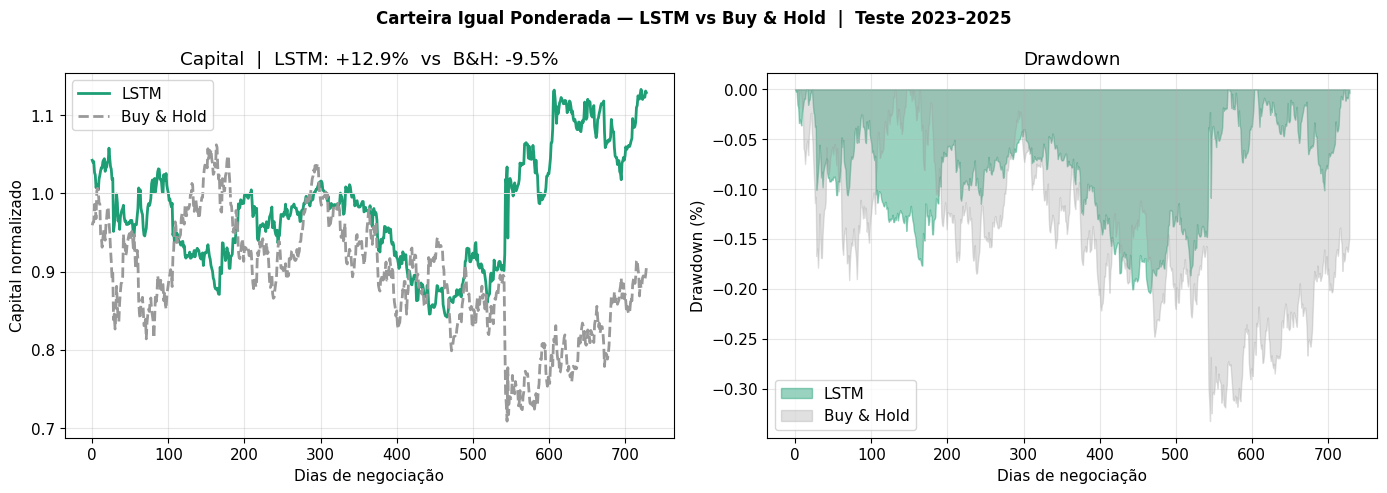

In [35]:
# Plot 2: Carteira + Drawdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Carteira Igual Ponderada — LSTM vs Buy & Hold  |  Teste 2023–2025',
             fontsize=12, fontweight='bold')

n = len(curvas['LSTM_Carteira'])
x = np.arange(n)

axes[0].plot(x, curvas['LSTM_Carteira'], color='#1D9E75', linewidth=2, label='LSTM')
axes[0].plot(x, curvas['BH_Carteira'],   color='#999',   linewidth=2,
             linestyle='--', label='Buy & Hold')
axes[0].axhline(1.0, color='#ddd', linewidth=0.7)
ret_l = curvas['LSTM_Carteira'][-1] - 1
ret_b = curvas['BH_Carteira'][-1]   - 1
axes[0].set_title(f'Capital  |  LSTM: {ret_l:+.1%}  vs  B&H: {ret_b:+.1%}')
axes[0].set_xlabel('Dias de negociação')
axes[0].set_ylabel('Capital normalizado')
axes[0].legend()

def drawdown_serie(curva):
    pico = np.maximum.accumulate(curva)
    return (curva - pico) / pico

axes[1].fill_between(x, drawdown_serie(curvas['LSTM_Carteira']),
                     color='#1D9E75', alpha=0.45, label='LSTM')
axes[1].fill_between(x, drawdown_serie(curvas['BH_Carteira']),
                     color='#999',   alpha=0.30, label='Buy & Hold')
axes[1].set_title('Drawdown')
axes[1].set_xlabel('Dias de negociação')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('carteira_lstm_vs_bh.png', dpi=150, bbox_inches='tight')
plt.show()

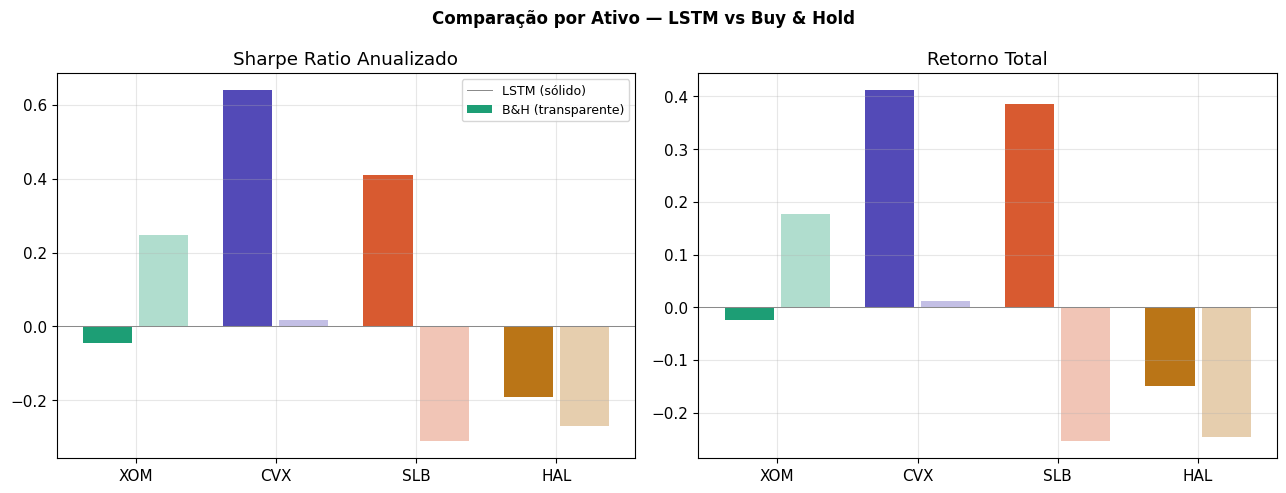

In [36]:
# Plot 3: Sharpe e Retorno total lado a lado
sub = df_res[df_res['Nome'].isin(TICKERS_ATIVOS)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Comparação por Ativo — LSTM vs Buy & Hold', fontsize=12, fontweight='bold')

for i, t in enumerate(TICKERS_ATIVOS):
    lstm_row = sub[(sub['Nome']==t) & (sub['Tipo']=='LSTM')].iloc[0]
    bh_row   = sub[(sub['Nome']==t) & (sub['Tipo']=='B&H')].iloc[0]

    axes[0].bar(i - 0.2, lstm_row['Sharpe'],        width=0.35, color=CORES[t], label='LSTM' if i==0 else '')
    axes[0].bar(i + 0.2, bh_row['Sharpe'],          width=0.35, color=CORES[t], alpha=0.35, label='B&H' if i==0 else '')
    axes[1].bar(i - 0.2, lstm_row['Retorno total'],  width=0.35, color=CORES[t])
    axes[1].bar(i + 0.2, bh_row['Retorno total'],    width=0.35, color=CORES[t], alpha=0.35)

for ax, titulo in zip(axes, ['Sharpe Ratio Anualizado', 'Retorno Total']):
    ax.axhline(0, color='#888', linewidth=0.7)
    ax.set_xticks(range(4))
    ax.set_xticklabels(TICKERS_ATIVOS)
    ax.set_title(titulo)

axes[0].legend(['LSTM (sólido)', 'B&H (transparente)'], fontsize=9)
plt.tight_layout()
plt.savefig('comparacao_sharpe_retorno.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Análise Final

Resumo interpretativo dos resultados para o relatório.

In [37]:
print('='*80)
print('ANÁLISE FINAL — Teste 2023–2025')
print('='*80)

cart_lstm = df_res[(df_res['Nome']=='Carteira') & (df_res['Tipo']=='LSTM')].iloc[0]
cart_bh   = df_res[(df_res['Nome']=='Carteira') & (df_res['Tipo']=='B&H')].iloc[0]
alpha_cart = cart_lstm['Retorno total'] - cart_bh['Retorno total']

print(f'\nCarteira LSTM:     retorno={cart_lstm["Retorno total"]:+.2%}  sharpe={cart_lstm["Sharpe"]:.3f}  MDD={cart_lstm["Max Drawdown"]:.2%}')
print(f'Carteira B&H:      retorno={cart_bh["Retorno total"]:+.2%}  sharpe={cart_bh["Sharpe"]:.3f}  MDD={cart_bh["Max Drawdown"]:.2%}')
print(f'Alpha (LSTM − B&H): {alpha_cart:+.2%}')

print('\nPor ativo:')
print(f'  {"Ativo":<6} {"LSTM":>8} {"B&H":>8} {"Alpha":>8} {"Veredicto"}')
print('  ' + '-'*50)
for t in TICKERS_ATIVOS:
    r_l = df_res[(df_res['Nome']==t) & (df_res['Tipo']=='LSTM')].iloc[0]['Retorno total']
    r_b = df_res[(df_res['Nome']==t) & (df_res['Tipo']=='B&H')].iloc[0]['Retorno total']
    alpha = r_l - r_b
    v = 'LSTM ganhou ✓' if alpha > 0 else 'B&H ganhou'
    print(f'  {t:<6} {r_l:>+8.2%} {r_b:>+8.2%} {alpha:>+8.2%}   {v}')

print(f'\nThreshold dinâmico: percentil p{PERCENTIL_OTIMO} (calibrado no treino por Sharpe)')
for t in TICKERS_ATIVOS:
    pct_op = df_res[(df_res['Nome']==t) & (df_res['Tipo']=='LSTM')].iloc[0]['% operando']
    print(f'  {t}: threshold={thresholds_por_ativo[t]:.6f}  →  {pct_op:.1%} dos dias operando')

ANÁLISE FINAL — Teste 2023–2025

Carteira LSTM:     retorno=+12.90%  sharpe=0.236  MDD=-20.43%
Carteira B&H:      retorno=-9.52%  sharpe=-0.135  MDD=-33.27%
Alpha (LSTM − B&H): +22.42%

Por ativo:
  Ativo      LSTM      B&H    Alpha Veredicto
  --------------------------------------------------
  XOM      -2.44%  +17.59%  -20.03%   B&H ganhou
  CVX     +41.13%   +1.20%  +39.93%   LSTM ganhou ✓
  SLB     +38.58%  -25.32%  +63.89%   LSTM ganhou ✓
  HAL     -14.86%  -24.59%   +9.73%   LSTM ganhou ✓

Threshold dinâmico: percentil p30 (calibrado no treino por Sharpe)
  XOM: threshold=0.005016  →  73.4% dos dias operando
  CVX: threshold=0.005788  →  66.0% dos dias operando
  SLB: threshold=0.006711  →  65.6% dos dias operando
  HAL: threshold=0.006546  →  61.2% dos dias operando


---
## 13. Análise de Robustez — 50 Seeds

Rodamos o pipeline completo 50 vezes com seeds diferentes para verificar se o alpha é **consistente** e não produto da inicialização dos pesos.

O CSV é salvo após cada run — se o notebook travar, ele retoma de onde parou.

> **Tempo estimado no Kaggle com GPU:** 15–30 min.

In [38]:
import os, time

N_SEEDS  = 50
SEEDS    = list(range(N_SEEDS))
CSV_PATH = 'robustez_runs.csv'


def run_seed(seed):
    """Treina do zero com seed fixo e retorna métricas do teste."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Modelo e otimizador
    m   = EnergyLSTM(input_size=len(FEATURES)).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=LR)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', patience=5, factor=0.5
    )

    # Treino com early stopping
    best_loss, best_w, pac = float('inf'), None, 0
    for epoch in range(1, EPOCHS + 1):
        m.train()
        ep_loss = 0.0
        for Xb, yb in loader_treino:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = sharpe_loss(m(Xb), yb, LAMBDA_SHARPE)
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
            ep_loss += loss.item()
        ep_loss /= len(loader_treino)
        sch.step(ep_loss)
        if ep_loss < best_loss:
            best_loss = ep_loss
            best_w    = {k: v.clone() for k, v in m.state_dict().items()}
            pac       = 0
        else:
            pac += 1
        if pac >= PATIENCE:
            break
    m.load_state_dict(best_w)

    # Threshold dinâmico — mesmo percentil ótimo já calibrado
    thr = {}
    for t in TICKERS_ATIVOS:
        Xtr, _ = janelas['treino'][t]
        thr[t] = np.percentile(np.abs(prever(m, Xtr)), PERCENTIL_OTIMO)

    # Avaliação no teste
    cap_lstm      = np.zeros(len(curvas['LSTM_XOM']))
    cap_bh        = np.zeros(len(curvas['BH_XOM']))
    ret_lstm_list = []

    for t in TICKERS_ATIVOS:
        Xte, yte = janelas['teste'][t]
        ypte     = prever(m, Xte)
        ret_l    = retornos_estrategia(yte, ypte, thr[t])
        cap_lstm += simular_capital(ret_l, CAPITAL_POR_ATIVO)
        cap_bh   += simular_capital(yte,   CAPITAL_POR_ATIVO)
        ret_lstm_list.append(ret_l)

    ret_cart = np.mean(ret_lstm_list, axis=0)

    return {
        'seed':         seed,
        'epocas':       epoch,
        'sharpe_cart':  sharpe_anualizado(ret_cart),
        'capital_lstm': cap_lstm[-1],
        'capital_bh':   cap_bh[-1],
        'alpha_usd':    cap_lstm[-1] - cap_bh[-1],
        'mdd_cart':     max_drawdown(np.exp(np.cumsum(ret_cart))),
        'lstm_ganhou':  int(cap_lstm[-1] > cap_bh[-1]),
    }


# Carrega runs anteriores se o CSV já existir
if os.path.exists(CSV_PATH):
    df_runs      = pd.read_csv(CSV_PATH)
    seeds_feitos = set(df_runs['seed'].tolist())
    print(f'CSV encontrado — {len(df_runs)} runs já salvos. Continuando...')
else:
    df_runs      = pd.DataFrame()
    seeds_feitos = set()
    print('Iniciando do zero — 50 runs')

pendentes = [s for s in SEEDS if s not in seeds_feitos]
print(f'Seeds pendentes: {len(pendentes)}\n')

for i, seed in enumerate(pendentes, start=1):
    t0  = time.time()
    res = run_seed(seed)
    dt  = time.time() - t0

    df_runs = pd.concat([df_runs, pd.DataFrame([res])], ignore_index=True)
    df_runs.to_csv(CSV_PATH, index=False)

    done   = len(seeds_feitos) + i
    status = '✓' if res['lstm_ganhou'] else '✗'
    print(f'[{done:>2}/50]  seed={seed:>2}  '
          f'sharpe={res["sharpe_cart"]:>+.3f}  '
          f'alpha=${res["alpha_usd"]:>+.0f}  '
          f'capital=${res["capital_lstm"]:>,.0f}  '
          f'epochs={res["epocas"]:>3}  {dt:.0f}s  {status}')

print(f'\nConcluído. CSV salvo em: {CSV_PATH}')


Iniciando do zero — 50 runs
Seeds pendentes: 50

[ 1/50]  seed= 0  sharpe=-0.588  alpha=$-146  capital=$776  epochs=100  51s  ✗
[ 2/50]  seed= 1  sharpe=+0.405  alpha=$+344  capital=$1,266  epochs=100  51s  ✓
[ 3/50]  seed= 2  sharpe=+0.021  alpha=$+181  capital=$1,103  epochs=100  51s  ✓
[ 4/50]  seed= 3  sharpe=+0.479  alpha=$+352  capital=$1,274  epochs=100  51s  ✓
[ 5/50]  seed= 4  sharpe=+0.608  alpha=$+519  capital=$1,442  epochs=100  51s  ✓
[ 6/50]  seed= 5  sharpe=+0.585  alpha=$+463  capital=$1,385  epochs=100  51s  ✓
[ 7/50]  seed= 6  sharpe=+0.525  alpha=$+418  capital=$1,340  epochs=100  51s  ✓
[ 8/50]  seed= 7  sharpe=-0.310  alpha=$-35  capital=$887  epochs=100  51s  ✗
[ 9/50]  seed= 8  sharpe=+0.200  alpha=$+190  capital=$1,112  epochs=100  51s  ✓
[10/50]  seed= 9  sharpe=-0.130  alpha=$+41  capital=$963  epochs=100  51s  ✓
[11/50]  seed=10  sharpe=+1.249  alpha=$+1061  capital=$1,983  epochs=100  51s  ✓
[12/50]  seed=11  sharpe=+0.333  alpha=$+340  capital=$1,262  epoch

ROBUSTEZ — 50 Seeds
  LSTM bateu B&H em 90% dos runs (45/50)

  Métrica                   Média      Std      Mín      Máx
  ────────────────────────────────────────────────────────
  Sharpe carteira            0.26     0.38    -0.59     1.25
  Alpha vs B&H ($)         284.15   242.27  -152.72  1060.69
  Capital final LSTM      1206.37   242.27   769.49  1982.91
  Max Drawdown              -0.25     0.08    -0.47    -0.12

  Capital B&H (fixo): $922.22


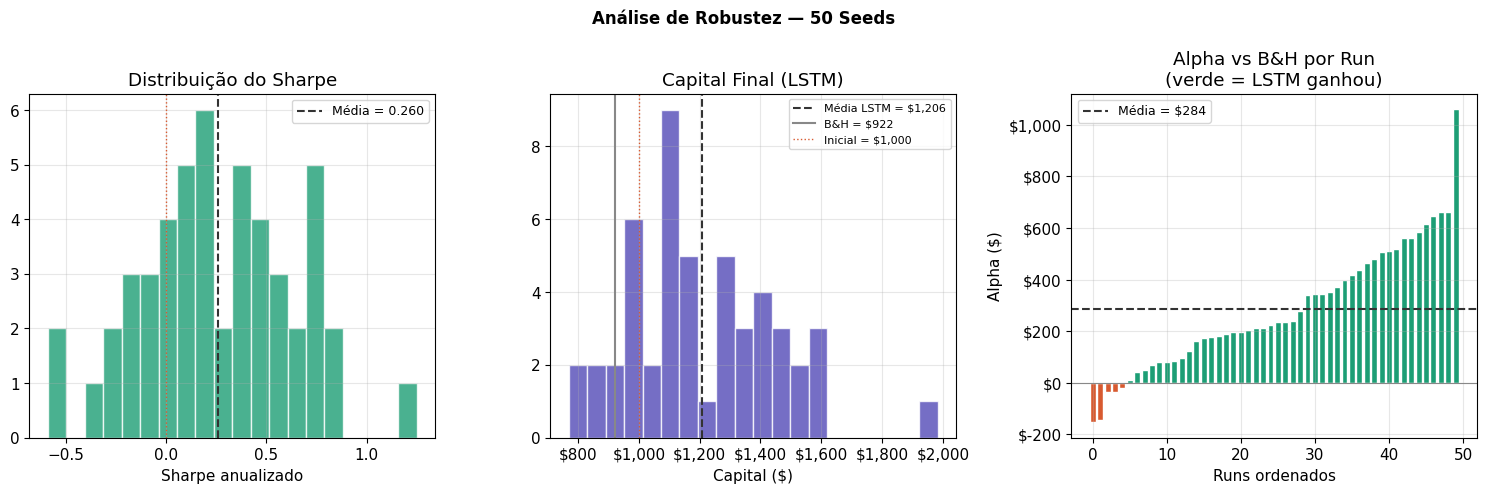

In [39]:
df_runs = pd.read_csv(CSV_PATH)

# Estatísticas
print('=' * 58)
print('ROBUSTEZ — 50 Seeds')
print('=' * 58)
print(f'  LSTM bateu B&H em {df_runs["lstm_ganhou"].mean():.0%} dos runs '
      f'({int(df_runs["lstm_ganhou"].sum())}/50)\n')
print(f'  {"Métrica":<22} {"Média":>8} {"Std":>8} {"Mín":>8} {"Máx":>8}')
print('  ' + '─' * 56)
for col, nome in [
    ('sharpe_cart',  'Sharpe carteira'),
    ('alpha_usd',    'Alpha vs B&H ($)'),
    ('capital_lstm', 'Capital final LSTM'),
    ('mdd_cart',     'Max Drawdown'),
]:
    s = df_runs[col]
    print(f'  {nome:<22} {s.mean():>8.2f} {s.std():>8.2f} {s.min():>8.2f} {s.max():>8.2f}')
print(f'\n  Capital B&H (fixo): ${df_runs["capital_bh"].mean():,.2f}')

# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Análise de Robustez — 50 Seeds', fontsize=12, fontweight='bold')

# 1. Distribuição do Sharpe
ax = axes[0]
ax.hist(df_runs['sharpe_cart'], bins=20, color='#1D9E75', alpha=0.8, edgecolor='white')
ax.axvline(df_runs['sharpe_cart'].mean(), color='#333', linewidth=1.5,
           linestyle='--', label=f'Média = {df_runs["sharpe_cart"].mean():.3f}')
ax.axvline(0, color='#D85A30', linewidth=1, linestyle=':')
ax.set_title('Distribuição do Sharpe')
ax.set_xlabel('Sharpe anualizado')
ax.legend(fontsize=9)

# 2. Capital final LSTM vs referências
ax = axes[1]
ax.hist(df_runs['capital_lstm'], bins=20, color='#534AB7', alpha=0.8, edgecolor='white')
ax.axvline(df_runs['capital_lstm'].mean(), color='#333', linewidth=1.5,
           linestyle='--', label=f'Média LSTM = ${df_runs["capital_lstm"].mean():,.0f}')
ax.axvline(df_runs['capital_bh'].mean(), color='#888', linewidth=1.5,
           linestyle='-', label=f'B&H = ${df_runs["capital_bh"].mean():,.0f}')
ax.axvline(CAPITAL_INICIAL, color='#D85A30', linewidth=1,
           linestyle=':', label=f'Inicial = ${CAPITAL_INICIAL:,.0f}')
ax.set_title('Capital Final (LSTM)')
ax.set_xlabel('Capital ($)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend(fontsize=8)

# 3. Alpha por run ordenado
ax = axes[2]
alphas = df_runs['alpha_usd'].sort_values().values
cores  = ['#1D9E75' if a > 0 else '#D85A30' for a in alphas]
ax.bar(range(len(alphas)), alphas, color=cores, edgecolor='white', width=0.8)
ax.axhline(0, color='#888', linewidth=0.8)
ax.axhline(df_runs['alpha_usd'].mean(), color='#333', linewidth=1.5,
           linestyle='--', label=f'Média = ${df_runs["alpha_usd"].mean():,.0f}')
ax.set_title('Alpha vs B&H por Run\n(verde = LSTM ganhou)')
ax.set_xlabel('Runs ordenados')
ax.set_ylabel('Alpha ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('robustez_50_seeds.png', dpi=150, bbox_inches='tight')
plt.show()
